# Time Travel

Checkpointer에 남은 과거 State를 조회하고, 특정 시점부터 다시 실행하거나 값을 바꿔 새로운 실행 경로를 만든다.

In [1]:
from typing import TypedDict

from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph

### Time Travel이란

Checkpointer를 연결한 그래프는 실행 과정의 State를 checkpoint로 기록한다. Time Travel은 이 기록을 조회하고 활용하는 기능이다.

| 동작 | 설명 |
|---|---|
| 조회 | 과거 checkpoint의 State와 다음 실행 노드를 확인한다. |
| Replay | 과거 값을 그대로 사용해 그 시점 이후를 다시 실행한다. |
| Fork | 과거 값을 수정한 뒤 다른 경로로 실행한다. |

### 실습 시나리오

`주제 정리 → 초안 작성 → 검토` 그래프를 만든다. 각 노드는 실행될 때 이름을 출력한다. 과거로 돌아갔을 때 어떤 노드가 다시 실행되는지 관찰한다.

In [2]:
class PostState(TypedDict, total=False):
    request: str
    topic: str
    draft: str
    review: str


def choose_topic(state: PostState):
    print("[실행] 주제 정리")
    return {"topic": f"{state['request']} 입문"}


def write_draft(state: PostState):
    print("[실행] 초안 작성")
    return {"draft": f"{state['topic']}: 쉽게 설명하는 게시글입니다."}


def review_draft(state: PostState):
    print("[실행] 검토")
    return {"review": f"검토 완료: {state['draft']}"}

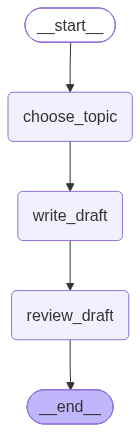

In [3]:
builder = StateGraph(PostState)
builder.add_node("choose_topic", choose_topic)
builder.add_node("write_draft", write_draft)
builder.add_node("review_draft", review_draft)
builder.add_edge(START, "choose_topic")
builder.add_edge("choose_topic", "write_draft")
builder.add_edge("write_draft", "review_draft")
builder.add_edge("review_draft", END)

graph = builder.compile(checkpointer=InMemorySaver())

display(Image(graph.get_graph().draw_mermaid_png()))


### 그래프 실행

In [ ]:
config = {"configurable": {"thread_id": "post-1"}}
result = graph.invoke({"request": "LangGraph"}, config)
print(result)

### 현재 State 조회

`get_state(config)`는 최신 `StateSnapshot`을 반환한다. `values`는 저장된 State, `next`는 다음에 실행할 노드, `config`는 `thread_id`와 `checkpoint_id`를 담고 있다. 실행이 끝났으므로 최신 snapshot의 `next`는 빈 튜플이다.

In [ ]:
current = graph.get_state(config)
print("values:", current.values)
print("next:", current.next)
print("config:", current.config)

### 과거 State 조회

`get_state_history(config)`는 최신 checkpoint부터 과거 순서로 snapshot을 반환한다.

In [ ]:
history = list(graph.get_state_history(config))

for index, snapshot in enumerate(history):
    checkpoint_id = snapshot.config["configurable"]["checkpoint_id"]
    print(
        f"{index}: next={snapshot.next}, "
        f"topic={snapshot.values.get('topic')!r}, "
        f"checkpoint_id={checkpoint_id[-8:]}"
    )

### 돌아갈 checkpoint 선택

`thread_id`가 하나의 실행 이력 전체를 구분한다면, `checkpoint_id`는 그 이력 안에 저장된 특정 시점을 구분한다. 각 snapshot의 `config`에는 두 값이 모두 들어 있다.

```text
thread_id: post-1
├── checkpoint_id: A  → 주제 정리 전
├── checkpoint_id: B  → 초안 작성 전
├── checkpoint_id: C  → 검토 전
└── checkpoint_id: D  → 실행 완료
```

각 snapshot의 `next`에는 그 시점에서 다음으로 실행할 노드가 담겨 있다. `next`가 `('write_draft',)`인 snapshot을 찾으면 초안을 작성하기 직전 상태로 돌아갈 수 있다. 과거 시점에서 실행하려면 `checkpoint_id`까지 포함된 해당 snapshot의 `config`를 사용한다.

In [ ]:
before_draft = None

for snapshot in history:
    if snapshot.next == ("write_draft",):
        before_draft = snapshot
        break

print("선택한 State:", before_draft.values)
print("다음 노드:", before_draft.next)
print("checkpoint_id:", before_draft.config["configurable"]["checkpoint_id"])

### Replay

Replay는 과거 checkpoint의 State를 변경하지 않고 그대로 다시 실행하는 방식이다.

선택한 checkpoint의 `config`와 함께 `None`을 입력하면 새 State를 넣지 않고 그 시점부터 실행한다. 완료된 `choose_topic`은 재실행하지 않고 `write_draft`부터 실행한다. 같은 값을 사용해도 이후 노드의 코드는 다시 호출된다.

In [ ]:
replayed = graph.invoke(None, before_draft.config)
print(replayed)

### Replay 이후의 checkpoint

Replay는 기존 checkpoint를 삭제하거나 덮어쓰지 않는다. 새 checkpoint는 같은 `thread_id`의 이력에 계속 추가되므로 `get_state_history()`의 결과는 최신순 목록으로 보인다.

각 checkpoint는 자신이 이어진 이전 checkpoint를 `parent_config`로 가리킨다. 과거의 B에서 Replay하면 새 checkpoint C'의 부모는 기존 최신 checkpoint D가 아니라 선택한 B가 된다. 이 부모 관계를 따라가면 실행 경로가 갈라진다.

```text
저장·조회 순서: A, B, C, D, C', D'
부모 관계:     A → B → C → D
                    └→ C' → D'
```

State 값이 기존 실행과 같더라도 새 checkpoint에는 새로운 `checkpoint_id`가 부여된다. `thread_id`만 사용해 `get_state()`를 호출하면 가장 최근에 생성된 checkpoint를 반환한다.

In [ ]:
history_after_replay = list(graph.get_state_history(config))

print("Replay 전 checkpoint 수:", len(history))
print("Replay 후 checkpoint 수:", len(history_after_replay))

for snapshot in history_after_replay:
    checkpoint_id = snapshot.config["configurable"]["checkpoint_id"]
    parent_id = None
    if snapshot.parent_config:
        parent_id = snapshot.parent_config["configurable"]["checkpoint_id"][-8:]

    print(
        f"checkpoint_id={checkpoint_id[-8:]}, "
        f"parent_id={parent_id}, next={snapshot.next}"
    )

### Fork

Fork는 과거 checkpoint의 State를 변경한 뒤, 변경된 State에서 다시 실행하는 방식이다.

`update_state()`로 과거 State를 바꾸면 기존 checkpoint를 덮어쓰지 않고 새 checkpoint를 만든다. `as_node="choose_topic"`은 해당 값을 그 노드가 작성한 것처럼 처리한다. 따라서 다음 노드인 `write_draft`부터 이어진다. 반환값은 새 checkpoint를 가리키는 config다.

### 기준 실행 생성

새로운 실행 이력을 생성하고 초안 작성 직전의 checkpoint를 선택한다.

In [ ]:
config = {"configurable": {"thread_id": "post-fork"}}
result = graph.invoke({"request": "LangGraph"}, config)
history = list(graph.get_state_history(config))

before_draft = None

for snapshot in history:
    if snapshot.next == ("write_draft",):
        before_draft = snapshot
        break

print("thread_id:", config["configurable"]["thread_id"])
print("checkpoint 수:", len(history))
print("선택한 State:", before_draft.values)

In [ ]:
fork_config = graph.update_state(
    before_draft.config,
    {"topic": "LangGraph Time Travel 심화"},
    as_node="choose_topic",
)

fork_state = graph.get_state(fork_config)
print("values:", fork_state.values)
print("next:", fork_state.next)

### 변경된 State에서 실행

새 checkpoint의 `next`에 지정된 `write_draft`부터 실행한다.

In [ ]:
forked = graph.invoke(None, fork_config)
print(forked)

### Fork 이후의 checkpoint

Fork도 기존 checkpoint를 삭제하거나 덮어쓰지 않는다. `update_state()`가 만든 수정 checkpoint와 이후 실행에서 생성된 checkpoint는 같은 `thread_id`의 이력에 계속 추가된다.

과거의 B를 기준으로 `update_state()`를 호출하면 수정된 State를 가진 checkpoint U가 생성되고, U의 부모는 B가 된다. 이어서 그래프를 실행하면 U의 `next`부터 실행되며 C'과 D'가 추가된다.

```text
저장·조회 순서: A, B, C, D, U, C', D'
부모 관계:     A → B → C → D
                    └→ U → C' → D'
                        ↑
                  update_state()
```

Replay와 달리 Fork에는 변경된 State를 저장하는 checkpoint U가 하나 더 존재한다. 각 checkpoint의 `parent_config`를 확인하면 기존 경로와 Fork 경로의 연결 관계를 확인할 수 있다.

In [ ]:
history_after_fork = list(graph.get_state_history(config))

print("Fork 전 checkpoint 수:", len(history))
print("Fork 후 checkpoint 수:", len(history_after_fork))

for snapshot in history_after_fork:
    checkpoint_id = snapshot.config["configurable"]["checkpoint_id"]
    parent_id = None
    if snapshot.parent_config:
        parent_id = snapshot.parent_config["configurable"]["checkpoint_id"][-8:]

    print(
        f"checkpoint_id={checkpoint_id[-8:]}, "
        f"parent_id={parent_id}, next={snapshot.next}"
    )

### 원래 경로와 분기 경로 비교

Fork 이후에도 원래 결과와 과거 checkpoint는 바뀌지 않는다.

In [ ]:
for key in ("topic", "draft", "review"):
    print(f"[{key}]")
    print("원래 경로:", result[key])
    print("분기 경로:", forked[key])
    print()

### 활용 사례

Replay는 과거 State를 그대로 사용해 특정 시점부터 다시 실행한다.

- 장애가 발생한 지점부터 다시 실행하며 Agent의 판단 과정 분석
- prompt, model, logic 수정 후 같은 과거 State에서 결과 비교
- 앞부분의 비싼 검색이나 Tool 호출 결과를 유지한 채 이후 단계 테스트

Fork는 과거 State의 일부를 수정한 뒤 새로운 경로로 실행한다.

- 사용자의 수정 요청이나 검토자의 피드백을 반영해 이후 작업 계속
- 동일한 중간 State에 서로 다른 조건을 적용해 결과 비교
- 긴 조사·분석 결과를 재사용해 여러 전략이나 결과 생성

서비스 화면에서는 checkpoint나 Fork라는 용어를 직접 보여주지 않고 사용자가 수행할 작업으로 표현한다.

| UI 기능 | 내부 동작 |
|---|---|
| `다시 생성` | 선택한 checkpoint에서 Replay |
| `이 단계부터 다시 실행` | 선택한 checkpoint에서 Replay |
| `수정 후 계속` | 중간 결과의 수정값을 State 필드에 반영한 뒤 Fork 실행 |
| `이 버전에서 다시 작성` | 선택한 버전의 checkpoint에서 Fork |

이처럼 Time Travel은 서비스에서 실행 결과를 다시 생성하거나 중간 결과를 수정해 이어가는 기능에 활용된다. 또한 장애가 발생한 실행을 재현하고 Agent의 판단 과정을 추적하는 등 디버깅과 운영에도 활용된다.

### 외부 작업 주의사항

State는 과거 checkpoint에서 다시 실행할 수 있지만, 이미 보낸 메일이나 처리한 결제는 되돌아가지 않는다. 이후 노드의 외부 작업은 중복 실행에 주의한다.

### 실습

초안 작성이 끝나고 검토하기 직전인 checkpoint를 찾아 `draft`를 직접 수정한 분기 경로를 만든다. 수정된 초안으로 `review_draft`만 실행되는지 확인한다.

In [10]:
practice_config = {"configurable": {"thread_id": "post-review-practice"}}
practice_result = graph.invoke({"request": "LangGraph"}, practice_config)

# TODO: next가 review_draft인 checkpoint를 찾으세요.
practice_history = list(graph.get_state_history(practice_config))

before_review = None

for snapshot in practice_history:
    if snapshot.next == ("review_draft",):
        before_review = snapshot
        break
# print("thread_id:", practice_config["configurable"]["thread_id"])
# print("checkpoint 수:", len(practice_history))
# print("선택한 State:", before_review.values)

replayed_result = graph.invoke(None, before_review.config)
print(replayed_result)

# TODO: update_state()로 draft를 수정하고 새 checkpoint config를 받으세요.
fork_config = graph.update_state(
    before_review.config,
    {"draft": "LangGraph Time Travel 심화"},
    as_node="write_draft",
)

fork_state = graph.get_state(fork_config)
# print("values:", fork_state.values)
# print("next:", fork_state.next)


# TODO: 수정된 checkpoint부터 실행하고 결과를 확인하세요.

forked_result = graph.invoke(None, fork_config)
print(forked_result)

[실행] 주제 정리
[실행] 초안 작성
[실행] 검토
[실행] 검토
{'request': 'LangGraph', 'topic': 'LangGraph 입문', 'draft': 'LangGraph 입문: 쉽게 설명하는 게시글입니다.', 'review': '검토 완료: LangGraph 입문: 쉽게 설명하는 게시글입니다.'}
[실행] 검토
{'request': 'LangGraph', 'topic': 'LangGraph 입문', 'draft': 'LangGraph Time Travel 심화', 'review': '검토 완료: LangGraph Time Travel 심화'}
